Département de génie électrique - Polytechnique Montréal

Analyse des signaux - ELE2700

TP4 version 4.0: A2025

---
Numéro d'équipe: #102

Noms, prénoms et matricules:

- Machraoui, Simon : 2487824

- Beaumier, Édouard : 2087482


>⚠ **Attention:**
>
> Avant de commencer à utiliser le `notebook`, assurez-vous de le sauvegarder dans votre Google drive personnel.
>


#$\color{#18a2f2}{\textbf{TP4 - Introduction à la détection radar}}$


##$\color{#a618f2}{\textbf{Mise en contexte:}}$

 Les radars sont des systèmes de détection d'objets fournissant la distance et la vitesse de déplacement d'un objet inconnu visé. Ce TP fera l'étude particulière des radar dits passifs.

 Un radar passif est un équipement qui ne transmet pas de signal radio, il détecte plutôt le passage de signaux d'intérêts en les comparant à un signal de référence. Nous utilisons alors l'opération d'inter-corrélation afin de déterminer si le signal reçu par le radar correspond au signal d'intérêt. Les applications varient, allant de la diffusion télévisée en direct, aux systèmes d'écoute et de surveillance militaires.

 L'avantage de ce type de radar face à un radar conventionnel est sa discrétion (sa présence n'est pas détectable par d'autres radars) ainsi que sa simplicité (seule l'étape de réception est requise, réduisant les coûts et la complexité du système).

 Voici un diagramme bloc général du fonctionnement du radar :

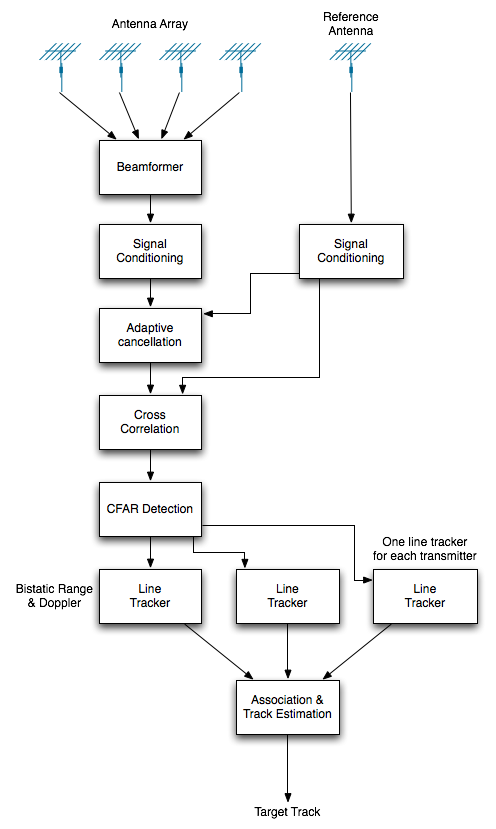

***Image tirée de : https://en.wikipedia.org/wiki/File:PassiveRadarSchematic.png***

Nous allons dans le cadre de ce TP nous concentrer sur l'étude du bloc d'intercorrélation.


# <font color='green'>  Fonctionnement de l'inter-corrélation </font>

L'inter-corrélation est une opération mathématique définie par l'expression suivante :


$$
\begin{align*}
  f(t) \star g(t) &= \int_{-\infty}^{+\infty} f(\tau)g(t+\tau)^* \,\mathrm{d}\tau.
\end{align*}
$$

Lors d'une inter-corrélation, deux fonctions, $f(t)$ et $g(t)$, sont comparées. Afin d'avoir l'intuition derrière cette opération, il faut tout d'abord considérer le produit des fonctions $f(\tau)g(t+\tau)$. Nous avons vu en classe que $g(t+\tau)$ n'est en réalité qu'un décalage de la fonction $g(\tau)$ vers la gauche (si $t$ est positif) ou vers la droite (si $t$ est négatif) lorsque nous considérons l'axe des abcisses $\tau$ utilisé pour l'intégrale. Déterminer l'inter-corrélation de deux fonctions revient donc à effectuer cette opération ainsi que l'intégrale par rapport à $\tau$ en balayant toutes les valeurs de $t$ (de $-∞$ à $+∞$)

#$\color{#18a2f2}{\textbf{TP4 - Exercices}}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## $\color{#03fc9d}{\textbf{Exercice 0,  à faire en préparation :}}$

$\color{orange}{\text{a)}}$ Calculer et tracer une fonction $g(t+\tau)$ triangulaire pour différents décalages $t$ :

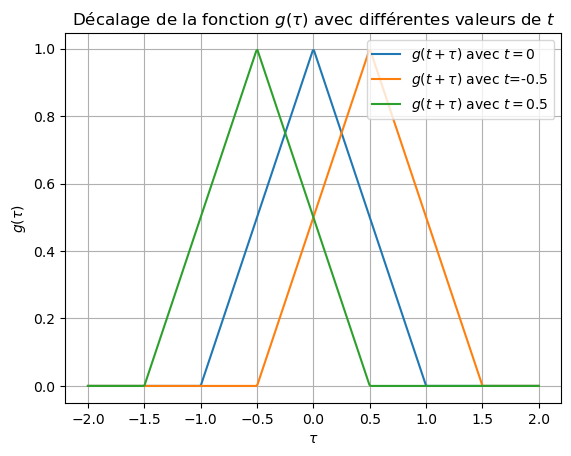

In [2]:
# Définition de la fonction g(t)
def g(t):
    return np.maximum(0, 1 - np.abs(t))

# Création de valeurs pour tau
tau = np.linspace(-2, 2, 400)

# Affichage de g(t) avec t = 0
plt.plot(tau, g(tau), label=r'$g(t+\tau)$ avec $t=0$')

# Affichage de g(t) avec t négatif (décalage vers la droite)
t_negatif = -0.5
plt.plot(tau, g(tau + t_negatif), label=r'$g(t+\tau)$ avec $t$=-0.5')

# Affichage de g(t) avec t positif (décalage vers la gauche)
t_positif = 0.5
plt.plot(tau, g(tau + t_positif), label=r'$g(t+\tau)$ avec $t=0.5$')

plt.xlabel(r'$\tau$')
plt.ylabel(r'$g(\tau)$')
plt.legend()
plt.grid(True)
plt.title(r'Décalage de la fonction $g(\tau)$ avec différentes valeurs de $t$')
plt.show()



Nous observons que lors de l'opération d'inter-corrélation, $t$ est balayé entre  $-\infty$  et  $+\infty$.

Lors de ce balayage, nous considérons une valeur donnée de $t$ et cherchons à obtenir l'aire sous la courbe du produit $f(\tau)g(t+\tau)$. L'étude des variations de cette aire fournie une idée sur la similarité des deux fonctions considérées.  Dans le cas particulier où nous avons $f(\tau) = g(\tau)$, l'inter-corrélation s'intéresse pour un $t$ donné, l'aire sous la courbe $f(\tau)f(t+\tau)$. Si les deux fonctions se superposent, i.e., $t = 0$, alors l'aire sous la courbe sera maximale, ce qui indique une similarité parfaite entre les deux fonctions. Dans le cas où $f(\tau) = g(\tau)$, nous parlons plus spécifiquement d'auto-corrélation.

$\color{orange}{\text{b)}}$  Considérer le cas de l'auto-corrélation d'une fonction carrée standard entre $t=3$ et $t=5$. Calculons l'aire sous la courbe pour $t=1$ dans l'intégrale d'auto-corrélation.

**Rappel** : une fonction rectangle est définie à l'aide de fonctions de Heaviside tel que pour un rectangle entre $t_1$ et $t_2$, nous avons:

$$
\mathrm{rect}(t)_{[t_1, t_2]} = u(t-t_2) - u(t-t_1).
$$

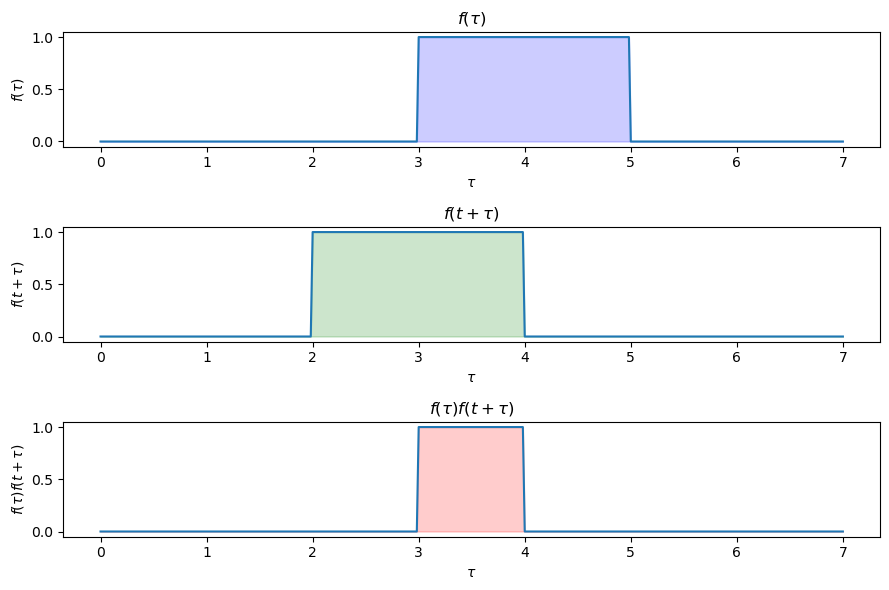

Aire sous la courbe du produit : 1.00


In [3]:

# Fonction carrée standard
def f(t):
    return np.where(np.logical_and(t >= 3, t < 5), 1, 0)

# Valeur de t fixée à 1
t = 1

# Séquence de valeurs pour tau
tau = np.linspace(0, 7, 400)

# Calcul de f(t)
ftau = f(tau)

# Calcul de f(t+tau)
ftau_t = f(t + tau)

# Calcul du produit f(t)*f(t+tau)
product = ftau * ftau_t

# Calcul de l'aire sous la courbe du produit
area_under_curve = np.trapz(product, tau)

# Affichage de f(t)
plt.figure(figsize=(9, 6))

plt.subplot(311)
plt.plot(tau, ftau)
plt.fill_between(tau, 0, ftau, alpha=0.2, color='blue')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$f(\tau)$')
plt.title(r'$f(\tau)$')

# Affichage de f(t+tau)
plt.subplot(312)
plt.plot(tau, ftau_t)
plt.fill_between(tau, 0, ftau_t, alpha=0.2, color='green')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$f(t+\tau)$')
plt.title(r'$f(t+\tau)$')

# Affichage du produit f(t)*f(t+tau)
plt.subplot(313)
plt.plot(tau, product)
plt.fill_between(tau, 0, product, alpha=0.2, color='red')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$f(\tau) f(t+\tau)$')
plt.title(r'$f(\tau) f(t+\tau)$')


plt.tight_layout()
plt.show()

# Affichage de l'aire sous la courbe du produit
print(f'Aire sous la courbe du produit : {area_under_curve:.2f}')



$\color{orange}{\text{c)}}$ Comparons l'aire sous la courbe pour différentes valeurs de $t$



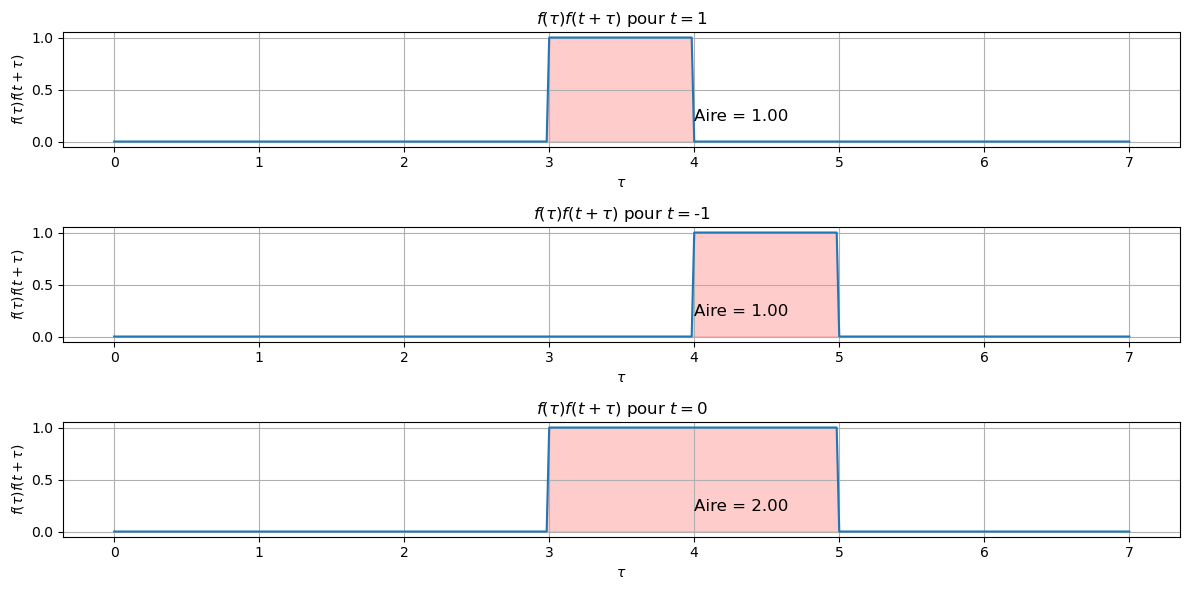

In [4]:

def f(t):
    return np.where(np.logical_and(t >= 3, t < 5), 1, 0)

# Séquence de valeurs pour t
tau = np.linspace(0, 7, 400)

# Différentes valeurs de tau
t_vec = [1, -1, 0]

# Créez une figure pour afficher les trois graphiques
plt.figure(figsize=(12, 6))

for t in t_vec:
    # Calcul de f(tau)
    ftau = f(tau)

    # Calcul de f(t+tau)
    ftau_t = f(tau + t)

    # Calcul du produit f(t)*f(t+tau)
    product = ftau * ftau_t

    # Calcul de l'aire sous la courbe du produit
    area_under_curve = np.trapz(product, tau)

    # Créez un subplot pour chaque tau
    plt.subplot(len(t_vec), 1, t_vec.index(t) + 1)

    # Affichage de f(t)*f(t+tau)
    plt.plot(tau, product, label=f'Aire = {area_under_curve:.2f} (tau = {t})')
    plt.fill_between(tau, 0, product, alpha=0.2, color='red')

    plt.xlabel(r'$\tau$')
    plt.ylabel(r'$f(\tau)f(t+\tau)$')
    plt.title(rf'$f(\tau)f(t+\tau)$ pour $t = ${t}')
    plt.grid(True)

    # Ajouter le texte pour afficher l'aire sous la courbe
    plt.text(4, 0.2, f'Aire = {area_under_curve:.2f}', fontsize=12, color='black')

plt.tight_layout()
plt.show()

Dans les applications radars, nous aurons un signal de retour différent de $f(t)$, que nous appelons $g(t)$. Afin de déterminer si $g(t)$ est un signal d'intérêt, nous devons le comparer à un signal de référence, typiquement celui-ci sera l'auto-corrélation de la fonction $f(t)$. Ceci sera discuté à l'Exercice 3.

## $\color{#03fc9d}{\textbf{Exercice 1, évalué en classe (8pt/20):}}$

$\color{orange}{\text{a) [code]}}$ Évaluer l'intégrale d'inter-corrélation entre les deux signaux suivants (utiliser la fonction d'inter-corrélation de votre choix, nous proposons `numpy.correlate`): $\color{red}{\textbf{(1pt/20)}}$



1.   Premier signal : signal rectangulaire ayant un maximum de 1, compris entre 3 et 5
2.   Second signal : signal rectangulaire ayant un maximum de 1, compris entre 1 et 3

>⚠ **Attention:**
>
> Utiliser un intervalle d'affichage symétrique pour l'inter-corrélation.
>
> Penser à afficher votre figure de manière descriptive (ici avoir des figures `signal1`, `signal2` et `intercorrélation` disposées les unes sous les autres semble être pertinent par exemple).
>



In [ ]:
# Écrire votre code ici pour a)

$\color{orange}{\text{b) [Démarche manuscrite]}}$ Considérer d'abord le signal rectangulaire $x(t)$:

$$
x(t) = \sum_{n \in \mathbb{Z}} \tilde{\Pi}(t-nT)
$$

où

\begin{align*}
\tilde{\Pi}(t) &= \begin{cases}
1, &\text{ si } 0 \leq t < T/2\\
-1, &\text{ si } T/2 \leq t < T\\
0, &\text{ sinon,}\end{cases}
\end{align*}

Déterminer analytiquement l'auto-corrélation du signal $x(t)$. $\color{red}{\textbf{(2pt/20)}}$



---

---


*Insérer une photo de vos démarches pour (b) (papier, $\LaTeX$ ou tablette)*.



---

---


$\color{orange}{\text{c) [code]}}$ Effectuer l'opération d'auto-corrélation numérique sur le signal $x(t)$ défini à la question précédente.  **(utiliser la fonction `correlate` de `numpy` avec l'option `mode="full"`)**

*  $T$ = 0.1s;
*   Durée du signal = 1 s;
*   Fréquence d'échantillonnage $f_\text{s}$ = 4000 Hz.

Comparer le résultat numérique au résultat théorique obtenu à la question b). Comment expliquez vous les différences? $\color{red}{\textbf{(1pt/20)}}$

>⚠ **Attention:**
>
> Afficher votre fonction d'inter-corrélation entre -1 et 1 pour le reste du TP. Pour ce faire en considérant un vecteur de temps $t$ standard, utiliser cette expression du temps lors de l'affichage d'un signal de corrélation :
>
>`t_autocorr = np.arange(-t[-1], t[-1] + 1/fs, 1/fs)`
>
>



In [ ]:
# Écrire votre code ici pour c)

$\color{orange}{\text{d) [Code]}}$ Introduire un délai dans le signal $x(t)$ et évaluer l'inter-corrélation entre le signal initial et sa version avec délai. Afficher le signal d'intercorrélation $\color{red}{\textbf{(1pt/20)}}$

*   Délai (en secondes) = Numéro d'équipe/1000.





In [ ]:
# Écrire votre code ici pour d)

$\color{orange}{\text{e) [code]}}$ Calculer le délai entre les maxima de l'inter-corrélation pour la question c) et d). $\color{red}{\textbf{(1pt/20)}}$


In [ ]:
# Écrire votre code ici pour e)

$\color{orange}{\text{f) [Texte]}}$ Expliquer en vos termes pourquoi choisir un délai s'approchant de la période du signal périodique initial fausse le calcul de délai avec l'inter-corrélation. $\color{red}{\textbf{(2pt/20)}}$

**Écrire votre réponse ici pour f).**

## $\color{#03fc9d}{\textbf{Exercice 2, évalué en classe (2pt/20):}}$
 À la lumière de vos expériences, choisir un signal périodique pour le calcul de délai dans le cadre d'un système radar (passif ou non) n'est pas une bonne option. Au TP-3, nous avons étudié avec profondeur la composition fréquentielle et le motif d'un signal *chirp* : c'est un signal fréquemment utilisé dans le contexte de systèmes radars passifs du fait de sa non-périodicité ainsi que de sa large couverture du domaine fréquentiel.

 Considérons l'étude du signal *chirp* suivant :

In [ ]:
def chirp_signal(f0, f1, t, T):
    # Générer un signal chirp continu
    return np.sin(2 * np.pi * (f0 * t + ((f1 - f0) / T) * t**2))

# Paramètres du signal chirp
f0 = 10  # Fréquence de départ du chirp (en Hz)
f1 = 100  # Fréquence finale du chirp (en Hz)
T = 1.0  # Durée du signal chirp (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
t = np.arange(0, T, 1/fs)

# Générer un signal chirp continu
signal = chirp_signal(f0, f1, t, T)

$\color{orange}{\text{a) [code]}}$ Générer un signal *chirp* bruité en retard de 0.2s à partir du signal chirp plus haut. Évaluer l'inter-corrélation entre le signal *chirp* fourni et sa version retardée et bruitée. **(utiliser `np.random.randn()` pour générer du bruit)**  $\color{red}{\textbf{(1.5pt/20)}}$

In [ ]:
# Écrire votre code ici pour a)

$\color{orange}{\text{b) [code]}}$ Afficher le signal *chirp*, son équivalent bruité et l'inter-corrélation des deux (rappel : faire un affichage sur $[-1,1]$ pour l'intercorrélation). $\color{red}{\textbf{(0.5pt/20)}}$

In [ ]:
# Écrire votre code ici pour b)



## $\color{#03fc9d}{\textbf{Exercice 3, devoir (10pt/20):}}$

Nous considérons maintenant un signal *chirp exponentiel* dont l'expression est donnée ci-dessous :

$$
x(t) = \text{cos}\left(\omega_0\left(\frac{T(k^{t/T}-1)}{\ln(k)}\right)\right),
$$
où :
*   $\omega_0$ = $2\pi$ Hz;
*   $k$ = e
*   $T$ = 1 s;
*   $f_s$ = 1000 Hz.




In [ ]:
def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
signal = chirp_signal(f0, f1, t, T)

$\color{orange}{\text{a) [Photos dans case texte]}}$ Donner l'expression analytique d'auto-corrélation d'un signal *chirp* avec lui-même. Prendre les paramètres suivants : $\color{red}{\textbf{(3pt/20)}}$

*   $\omega_0$ = $2\pi$ Hz;
*   $k$ = e;
*   $T$ = 1 s.

Ainsi, donner l'expression d'autocorrélation du signal:

$$
\cos\left(2\pi \mathrm{e}^t\right).
$$

Utiliser les trois premiers termes du développement en série de Taylor pour approximer $\mathrm{e}^t$ comme au TP-3.


---

---


*Insérer une photo de vos démarches pour (e) (papier, $\LaTeX$ ou tablette)*.



---

---

# <font color='green'> Analyse d'un signal radar issu d'un environnement et d'une cible inconnus </font>


À partir de maintenant, nous nous plaçons dans le contexte de simulation d'un radar standard. Le signal suit donc le chemin suivant: aller jusqu'à une cible, réflexion depuis la cible et retour vers le radar. L'aller et le retour se fait dans un milieu de propagation. Ce milieu sera simulé par un environnment boîte noire. Cet aller-retour est effectué pour chaque cible présente.

Télécharger sur `Moodle` le fichier `blackbox_tp4.so` et rouler la commande suivante.

In [ ]:
from google.colab import files

S'assurer d'avoir téléchargé le fichier `blackbox_tp4.so` avant l'étape suivante. Le sélectionner en appuyant sur `Choose Files`.

In [ ]:
uploaded = files.upload() # Décommenter la première fois que vous roulez le code pour importer votre fichier blackbox_tp4 (ne pas oublier de recommenter un fois cela fait!)

**Vérifier** que le fichier a bien été téléchargé dans l'environnement actuel. Si jamais vous voulez retirer un fichier, utiliser la commande suivante:

In [ ]:
!ls -lh
# !rm blackbox_tp4.so  #Commande pour retirer un fichier, si nécessaire. Laisser en commentaire.

Une fois le fichier `blackbox_tp4` importé, rouler la commande suivante:

In [ ]:
import blackbox_tp4

Le fichier `blackbox_tp4` contient l'exécutable de la fonction boîte noire `blackbox1`, que nous considérons être un milieu de propagation contenant de l'air. La fonction accepte les arguments suivants:


*   Argument 1: signal d'entrée.

Elle retourne le signal modifié dû à son passage dans le milieu de propagation.
Voici un exemple d'utilisation:

`blackbox_tp4.blackbox1(signal)`

$\color{orange}{\text{b) [code]}}$ Avec l'aide de la boîte noire fournie : Injecter le signal *chirp exponentiel* (signal décrit dans la case de code au début de l'exercice 3 où $\omega_0$ = $2\pi$ Hz, $k$ = e, $T$ = 1 s) dans la boîte noire et évaluer l'inter-corrélation entre le signal *chirp exponentiel* et sa sortie. $\color{red}{\textbf{(1pt/20)}}$

In [ ]:
# Écrire votre code ici pour b)


$\color{orange}{\text{c) [code et interprétation]}}$  Afficher sur le même graphique le signal *chirp exponentiel* d'entrée, le signal en sortie de la boîte noire, le signal d'auto-corrélation du *chirp exponentiel* et le signal d'inter-corrélation entre *chirp exponentiel* et la sortie. Expliquer pourquoi l'inter-corrélation se déplace à gauche ou à droite (selon ce qui est observeé) en comparaison à l'auto-corrélation. $\color{red}{\textbf{(3pt/20)}}$

In [ ]:
# Écrire votre code ici pour c)

$\color{orange}{\text{d) [code et interprétation]}}$ Refaire l'exercice 3c) en utilisant un signal sinusoidal au lieu du signal chirp. Comment interprétez vous ces résultats? Quel signal permet une meilleure analyse? $\color{red}{\textbf{(1pt/20)}}$

In [ ]:
# Écrire votre code ici pour d)

$\color{orange}{\text{e) [code]}}$  Déterminer la distance entre les cibles et le radar en considérant que l'unité de temps est donnée en microsecondes (ne pas oublier que le signal fait un aller-retour avec les cibles) $\color{red}{\textbf{(2pt/20)}}$



> **Note** : Nous supposons ici que le temps entre les maxima d'inter-corrélation correspond au délai réel entre les signaux. En temps normal, nous ne supposerions pas que le delai entre les maxima des deux interc-orrélations corresponde au délai exact, nous passerions par des tables qui associent pour notre système le délai d'intercorrélation au délai réel observé.


In [ ]:
# Écrire votre code ici pour e)

## $\color{#03fc9d}{\textbf{Précisions pour la remise:}}$

* Pour chaque exercice, répondre en ajoutant des cases de code ou de texte en dessous de la question.

* Remettez sur moodle un fichier `.ipynb` ainsi qu'une version `pdf` contenant seulement l'exercice 3) avec toutes les librairies et importations nécessaires pour que le code roule.

* Indiquer noms, matricules et numéro d'équipe au début du `notebook`.